# AEM Final

In [1]:
import requests
import pandas as pd

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
params = {
    "$limit": 5
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()
df = pd.DataFrame(data)

print(df)
print(df.columns.tolist())

         id case_number                     date  \
0  14181385    JK235183  2026-04-24T00:00:00.000   
1  14179690    JK233144  2026-04-24T00:00:00.000   
2  14177257    JK230189  2026-04-24T00:00:00.000   
3  14182042    JK235908  2026-04-24T00:00:00.000   
4  14176383    JK229147  2026-04-24T00:00:00.000   

                                 block  iucr             primary_type  \
0                015XX S FAIRFIELD AVE  0281  CRIMINAL SEXUAL ASSAULT   
1  091XX S DR MARTIN LUTHER KING JR DR  0610                 BURGLARY   
2                052XX S LAKE PARK AVE  0420                  BATTERY   
3                 035XX S MICHIGAN AVE  1220       DECEPTIVE PRACTICE   
4                  078XX S ABERDEEN ST  0497                  BATTERY   

                                         description  \
0                                     NON-AGGRAVATED   
1                                     FORCIBLE ENTRY   
2            AGGRAVATED - KNIFE / CUTTING INSTRUMENT   
3                   THEF

In [3]:
import requests
import pandas as pd

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
params = {
    "$select": "date,primary_type,description,location_description,arrest,domestic,district,ward,community_area,latitude,longitude",
    "$where": "date >= '2024-01-01T00:00:00'",
    "$limit": 50000
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()
df = pd.DataFrame(data)

print("Shape before cleaning:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["district"] = pd.to_numeric(df["district"], errors="coerce")
df["ward"] = pd.to_numeric(df["ward"], errors="coerce")
df["community_area"] = pd.to_numeric(df["community_area"], errors="coerce")

df = df.dropna(subset=["date"])

df["primary_type"] = df["primary_type"].astype(str).str.strip().str.upper()
df["location_description"] = df["location_description"].astype(str).str.strip().str.upper()
df["description"] = df["description"].astype(str).str.strip().str.upper()

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["year"] = df["date"].dt.year
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

print("\nShape after cleaning:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nPreview:")
print(df.head())

df.to_csv("chicago_crimes_2024_clean.csv", index=False)
print("\nSaved file: chicago_crimes_2024_clean.csv")

Shape before cleaning: (50000, 11)

Columns:
['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'district', 'ward', 'community_area', 'latitude', 'longitude']

Shape after cleaning: (50000, 17)

Data types:
date                    datetime64[ns]
primary_type                    object
description                     object
location_description            object
arrest                            bool
domestic                          bool
district                         int64
ward                             int64
community_area                 float64
latitude                       float64
longitude                      float64
hour                             int32
day_of_week                     object
month                            int32
month_name                      object
year                             int32
is_weekend                        bool
dtype: object

Missing values:
date                      0
primary_type              0
descript

In [4]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print(df.head())
print(df.describe(include="all"))

(50000, 17)
['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'hour', 'day_of_week', 'month', 'month_name', 'year', 'is_weekend']
date                    datetime64[ns]
primary_type                    object
description                     object
location_description            object
arrest                            bool
domestic                          bool
district                         int64
ward                             int64
community_area                 float64
latitude                       float64
longitude                      float64
hour                             int32
day_of_week                     object
month                            int32
month_name                      object
year                             int32
is_weekend                        bool
dtype: object
date                      0
primary_type              0
description               0
location_d

In [4]:
df_map = df.dropna(subset=["latitude", "longitude"]).copy()
df_map.to_csv("crimes_map_ready.csv", index=False)

In [5]:
print("Cleaned dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nPreview:")
display(df.head())

Cleaned dataset shape: (50000, 17)

Columns:
['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'hour', 'day_of_week', 'month', 'month_name', 'year', 'is_weekend']

Missing values:
date                      0
primary_type              0
description               0
location_description      0
arrest                    0
domestic                  0
district                  0
ward                      0
community_area            3
latitude                258
longitude               258
hour                      0
day_of_week               0
month                     0
month_name                0
year                      0
is_weekend                0
dtype: int64

Data types:
date                    datetime64[ns]
primary_type                    object
description                     object
location_description            object
arrest                            bool
domestic                

,date,primary_type,description,location_description,arrest,domestic,district,ward,community_area,latitude,longitude,hour,day_of_week,month,month_name,year,is_weekend
0,2024-01-01,OFFENSE INVOLVING CHILDREN,CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,RESIDENCE,False,True,5,9,50.0,41.688400,-87.607115,0,Monday,1,January,2024,False
1,2024-01-01,OTHER OFFENSE,OTHER CRIME AGAINST PERSON,APARTMENT,False,False,8,23,56.0,41.795075,-87.784331,0,Monday,1,January,2024,False
2,2024-01-01,MOTOR VEHICLE THEFT,AUTOMOBILE,APARTMENT,False,True,16,31,15.0,NaN,NaN,0,Monday,1,January,2024,False
3,2024-01-01,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,False,5,9,53.0,NaN,NaN,0,Monday,1,January,2024,False
4,2024-01-01,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,SCHOOL - PUBLIC GROUNDS,False,False,1,3,33.0,NaN,NaN,0,Monday,1,January,2024,False


We retrieved the Chicago Crimes dataset through the Socrata Open Data API and selected key variables related to offense type, location, arrest status, and geography. The dataset was filtered to records from 2024 onward and cleaned by converting the date column to datetime format and relevant location fields to numeric format. We then created additional time-based variables, including hour, day of week, month, month name, year, and a weekend indicator. The cleaned dataset contains 50,000 records and 17 variables, with only a small number of missing values in geographic fields.


This section examines temporal crime patterns in the cleaned Chicago crimes dataset. We focus on how incident counts vary by hour, day of week, and month, and we also compare arrest rates across time periods. The goal is to identify whether crime incidents are evenly distributed over time or concentrated in specific recurring periods.

Shape: (50000, 17)

Columns:
['date', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'hour', 'day_of_week', 'month', 'month_name', 'year', 'is_weekend']

Crime count by hour:
hour
0     3467
1     1496
2     1354
3     1250
4     1045
5      895
6      962
7     1285
8     1867
9     2242
10    2219
11    2308
12    2947
13    2353
14    2398
15    2763
16    2753
17    2775
18    2628
19    2585
20    2465
21    2186
22    1989
23    1768
Name: count, dtype: int64

Crime count by day of week:
day_of_week
Monday       7605
Tuesday      7221
Wednesday    7370
Thursday     7487
Friday       7427
Saturday     6579
Sunday       6311
Name: count, dtype: int64

Crime count by month:
month_name
January     19653.0
February    19948.0
March       10399.0
Name: count, dtype: float64

Arrest rate by hour:
hour
0     0.097779
1     0.153075
2     0.135155
3     0.116800
4     0.096651
5     0.094972
6    

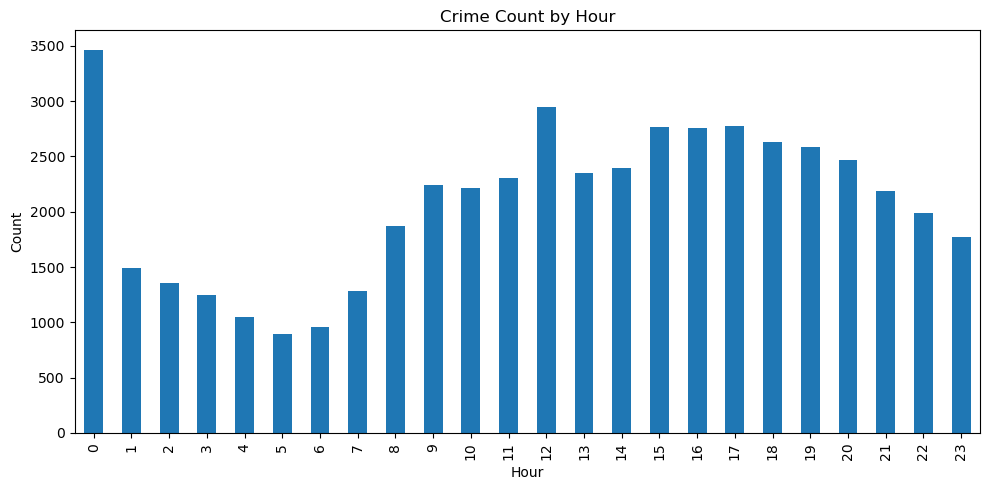

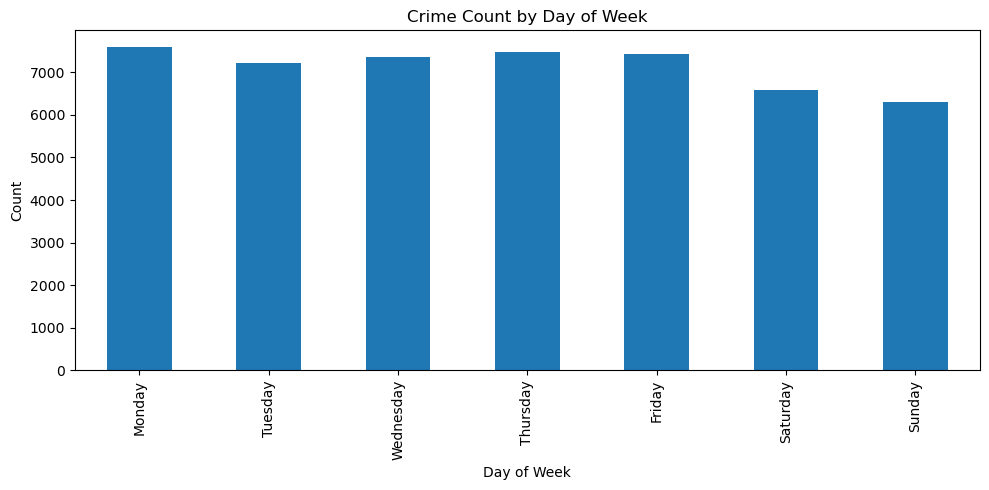

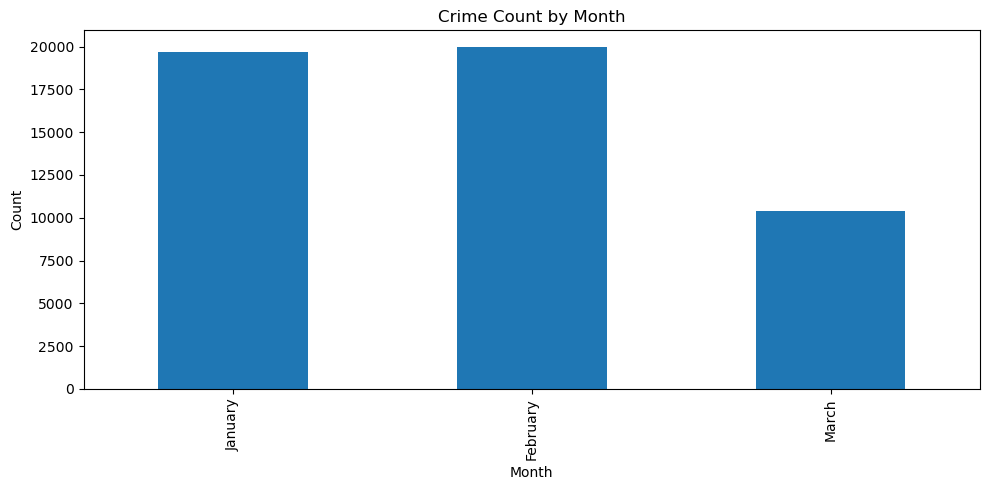

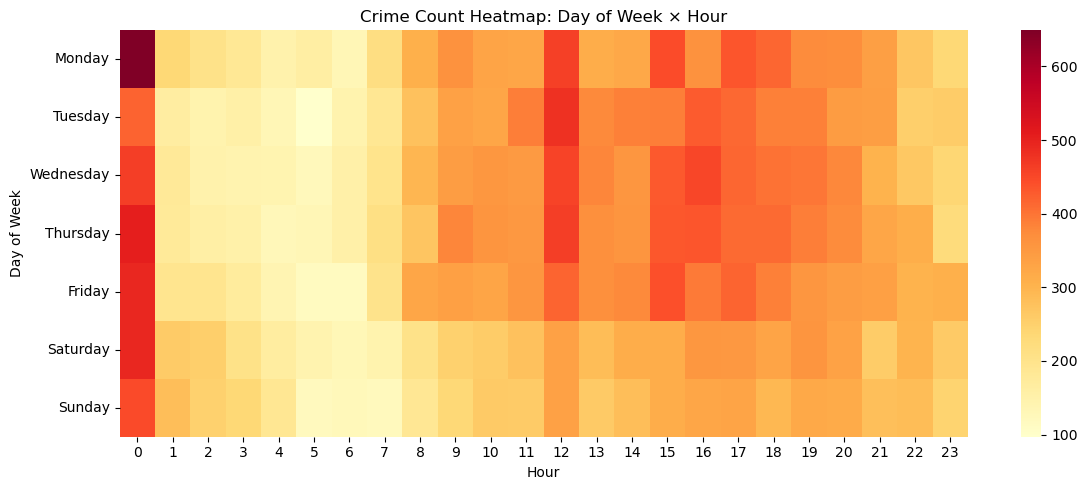

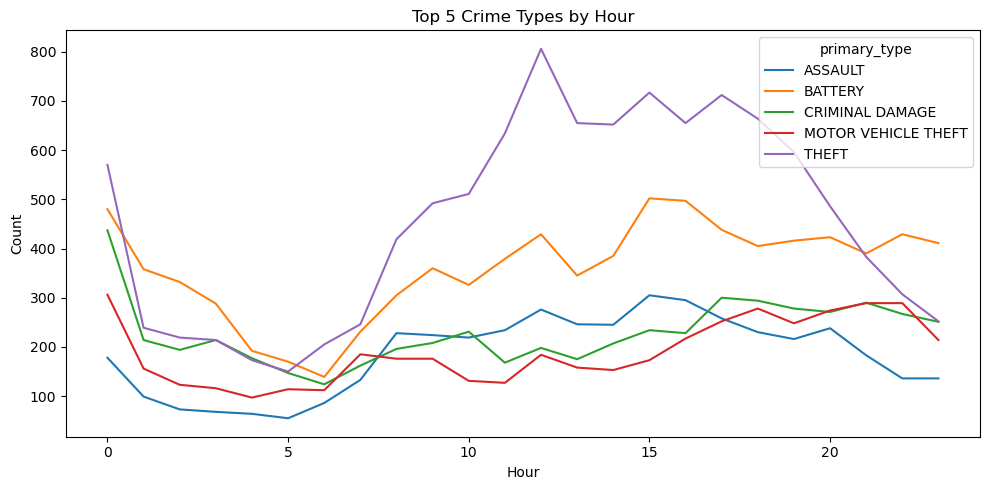

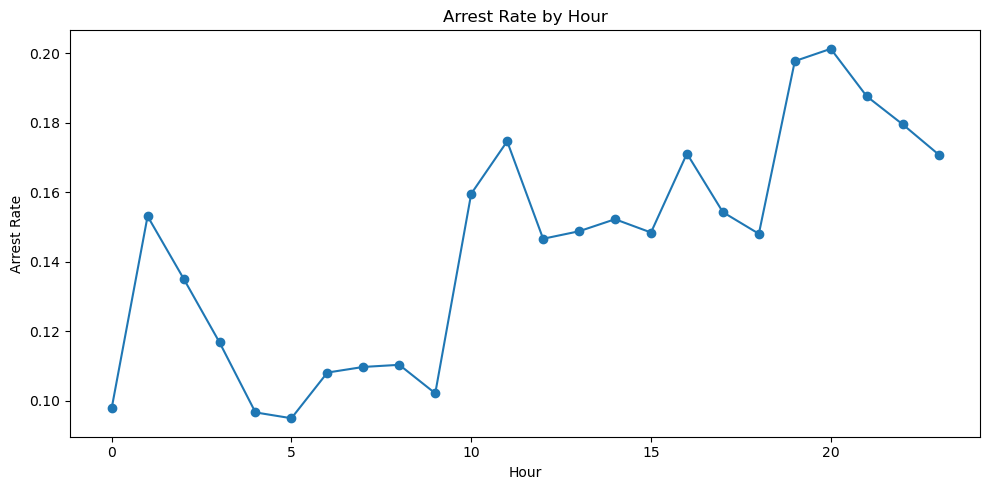

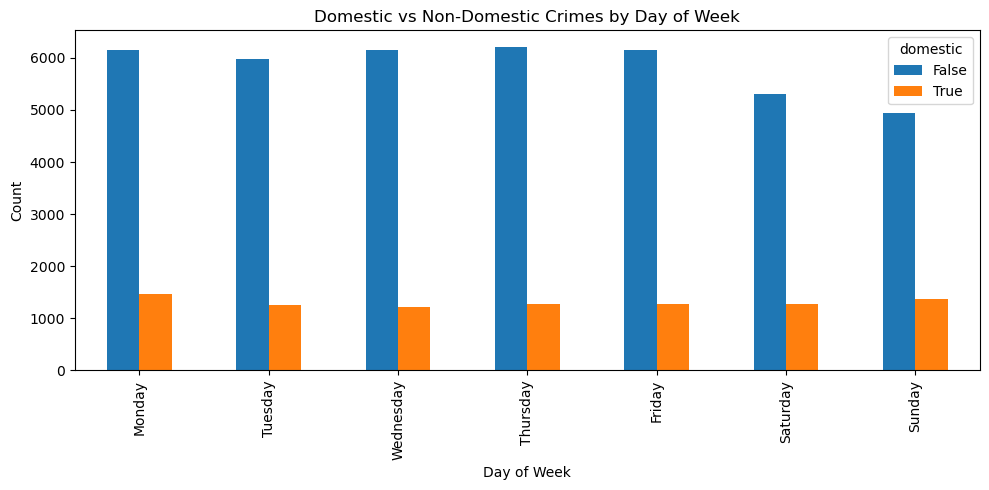

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("chicago_crimes_2024_clean.csv")
df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nCrime count by hour:")
print(df["hour"].value_counts().sort_index())

print("\nCrime count by day of week:")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(df["day_of_week"].value_counts().reindex(weekday_order))

print("\nCrime count by month:")
month_order = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]
print(df["month_name"].value_counts().reindex(month_order).dropna())

print("\nArrest rate by hour:")
arrest_by_hour = df.groupby("hour")["arrest"].mean().sort_index()
print(arrest_by_hour)

print("\nArrest rate by day of week:")
arrest_by_day = df.groupby("day_of_week")["arrest"].mean().reindex(weekday_order)
print(arrest_by_day)

top5_crimes = df["primary_type"].value_counts().head(5).index.tolist()
df_top5 = df[df["primary_type"].isin(top5_crimes)].copy()

plt.figure(figsize=(10, 5))
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Crime Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
df["day_of_week"].value_counts().reindex(weekday_order).plot(kind="bar")
plt.title("Crime Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

month_counts = df["month_name"].value_counts().reindex(month_order).dropna()
plt.figure(figsize=(10, 5))
month_counts.plot(kind="bar")
plt.title("Crime Count by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

heatmap_data = df.groupby(["day_of_week", "hour"]).size().unstack(fill_value=0).reindex(weekday_order)
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Crime Count Heatmap: Day of Week × Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

top5_hourly = df_top5.groupby(["hour", "primary_type"]).size().unstack(fill_value=0)
plt.figure(figsize=(10, 5))
top5_hourly.plot(ax=plt.gca())
plt.title("Top 5 Crime Types by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
arrest_by_hour.plot(marker="o")
plt.title("Arrest Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Arrest Rate")
plt.tight_layout()
plt.show()

domestic_time = df.groupby(["day_of_week", "domestic"]).size().unstack(fill_value=0).reindex(weekday_order)
plt.figure(figsize=(10, 5))
domestic_time.plot(kind="bar", ax=plt.gca())
plt.title("Domestic vs Non-Domestic Crimes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Temporal Analysis

This section examines temporal crime patterns in the Chicago crimes dataset. We focus on how incident counts vary by hour, day of week, and month, and we also compare arrest rates across time periods. The goal is to identify whether crime incidents are evenly distributed over time or concentrated in specific recurring periods.

### Crime Count by Hour
The hourly distribution shows that crime incidents are not evenly spread throughout the day. Incident counts are highest at **12:00 AM (3,467 cases)**, then decline sharply during the early morning hours, reaching their lowest point around **5:00 AM (895 cases)**. After that, counts begin to rise again in the morning, increase through midday, and remain relatively high during the late afternoon and evening. Another clear high point appears at **12:00 PM (2,947 cases)**, and crime counts stay elevated from roughly **3:00 PM to 8:00 PM**, with counts above 2,400 during each of those hours.

This pattern suggests that crime activity is concentrated in a few specific time windows rather than evenly distributed across the day. In particular, midnight, midday, and the late afternoon to evening period stand out as the busiest time periods in the current sample.

### Crime Count by Day of Week
When incidents are grouped by day of week, weekdays generally have slightly higher crime counts than weekends. **Monday has the highest count (7,605 cases)**, followed by Thursday and Friday, while **Sunday has the lowest count (6,311 cases)**. Saturday is also lower than most weekdays.

This suggests that, within the current time window, crime activity is somewhat more concentrated during the workweek than on weekends. However, the differences across days are not extremely large, so the day-of-week pattern appears moderate rather than dramatic.

### Crime Count by Month
The monthly distribution shows **19,653 incidents in January**, **19,948 in February**, and **10,399 in March**. Since the dataset currently covers only part of the year, these monthly counts should be interpreted carefully. The lower March total does not necessarily mean that crime decreased in March overall; it may simply reflect that the dataset only includes part of the month.

For this reason, the monthly chart is useful for showing the current sample coverage, but it should not be used to make strong conclusions about seasonal trends.

### Day of Week × Hour Heatmap
The heatmap combines both weekday and hourly patterns and provides the clearest summary of temporal concentration. The brightest areas appear around **12:00 AM**, **12:00 PM**, and the **late afternoon to early evening hours**, especially on weekdays. Monday through Friday show stronger concentrations in these periods, while weekends are somewhat less intense overall.

This supports the earlier results from the bar charts: crime incidents are concentrated in recurring periods of the day, and weekday activity tends to be slightly higher than weekend activity.

### Top 5 Crime Types by Hour
The hourly comparison of the top five crime types shows that the most common offense categories do not all follow the same daily rhythm. **Theft** remains the most frequent category across most hours and rises strongly around midday and in the afternoon. **Battery** also remains relatively high across the day, while **motor vehicle theft**, **assault**, and **criminal damage** show different hourly patterns with lower overall counts.

This suggests that temporal concentration is shaped not only by total crime volume, but also by differences in the timing of specific offense types.

### Arrest Rate by Hour
The arrest rate by hour does not fully match the hourly crime count pattern. Although incident counts are highest at midnight, the arrest rate at **12:00 AM is relatively low (0.098)**. By contrast, arrest rates become much higher in the evening, especially around **7:00 PM (0.198)** and **8:00 PM (0.201)**, which are the highest values in the day. Rates also rise during late morning and afternoon hours, such as **11:00 AM (0.175)** and **4:00 PM (0.171)**.

This shows that the time periods with the most reported crime are not always the same as the time periods with the highest arrest rates. In other words, incident volume and system response do not move in exactly the same way across the day.

### Arrest Rate by Day of Week
Arrest rates vary less across days of the week than crime counts do. The values range from **0.143 on Wednesday** to **0.154 on Sunday**, with Saturday and Sunday slightly higher than several weekdays. Overall, these differences are modest.

This suggests that while crime counts show some weekday concentration, arrest outcomes are more stable across the week, with only a slight tendency toward higher arrest rates on weekends.

### Domestic vs Non-Domestic Crimes by Day of Week
Across every day of the week, non-domestic crimes are far more common than domestic crimes. Domestic-related incidents remain a smaller share of the total throughout the week, although they still appear consistently every day. Sunday appears to have a slightly higher domestic count than some other days, but the overall daily pattern is still dominated by non-domestic incidents.

This result is useful as a supporting comparison, though it is less central than the hourly and arrest-rate findings.

## Key Takeaways
There are three main findings from the temporal analysis. First, crime incidents are concentrated in specific parts of the day, especially at midnight, around noon, and during the late afternoon and evening. Second, weekday crime counts are somewhat higher than weekend counts in the current sample. Third, arrest rates do not follow exactly the same pattern as incident counts, with the highest arrest rates appearing in the evening rather than at the hour with the most incidents.

These findings suggest that temporal patterns matter not only for understanding when crime happens, but also for understanding when public safety responses appear to be more or less effective.